In [1]:
import sys
sys.path.insert(0, '/home/lutein/Projects/class-gedf-test-04/build/temp.linux-x86_64-cpython-313')
import classy
print(classy.__file__)
import numpy as np

/home/lutein/anaconda3/envs/drdm/lib/python3.13/site-packages/classy/__init__.py


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import copy

# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
# from getdist import plots, MCSamples
# print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))
import matplotlib.pyplot as plt
import IPython

from matplotlib import rcParams

config = {
    "font.family":'serif',
    "font.size": 20,
    # "mathtext.fontset":'stix',
    # "font.serif": ['SimSun'],
    "text.usetex": True,
    "savefig.dpi": 600,
    "xtick.direction": 'in',
    "ytick.direction": 'in'
}
rcParams.update(config)

In [1]:
1/0.8

1.25

In [3]:
model = classy.Class()

k = 1e-2  # 1/Mpc

model.set({'ln10^{10}A_s': 3.038, 
            'n_s': 0.99, 
            'H0': 73.62, # Do not use theta_s as input parameter. A bug to be fixed.
            # 'theta_s_100': 1.041783,
            # 'h': 0.67810,
            'omega_b': 0.02233, 
            'omega_cdm': 0.1182, 
            'tau_reio': 0.05430842,
            # 'rho_edf': 0.,
            # 'rho_gedf': 351.49/2., # We set rho_gedf at ac (a critical redshift of EoS transition) as input parameter, and f_gedf as a derived parameter. Instead, we can modify the code to use f_gedf as input parameter and use shooting method to get rho_gedf.
            'f_gedf': 0.1, # The fraction of GEDF at a_ini_over_a_today_default, which is a very early time when the universe is radiation dominated. We use this parameter to control the amount of GEDF in the early universe, and it can be used to constrain the model with CMB data.
            'ac_gedf': 1./2500,
            # 'ac_gedf': 1./10000,
            's_a_gedf': 3., # A random number controlling the tanh function
            # 'cs2_drdm': 1.,
            'wi_edf': -1.,
            'wf_edf': 1.,
            # 'wf_gedf_i': 1.30,
            # 'use_pheno_w': 'no',
            # 'wf_edf_inf': 'no',
            # 'p_at_gedf': 1./0.8,
            # 'sa_at': 3.,
            'f_gedf_2': 0.05,
            'ac_gedf_2': 1./9000.,
            'wi_gedf_2': -1.,
            'wf_gedf_2': 1.,
            's_a_gedf_2': 3.,
            'Theta_i_edf': np.pi - 1.,
            'k_output_values':k,
            'gauge':'synchronous',
            # 'gauge': 'newtonian',
            'background_verbose': 3.,
            'start_small_k_at_tau_c_over_tau_h': 0.000004,
            'a_ini_over_a_today_default': 1e-16,
            'has_gedf_perturbations': 'yes',
            'has_gedf_2_perturbations': 'yes',
            'l_max_scalars': 5000,
            # 'get_perturbations_in_current_gauge': 'yes',
            })
model.set({'output':'tCl,pCl,lCl,mPk','lensing':'yes','P_k_max_1/Mpc':3.0})
model.compute()

print(model.get_current_derived_parameters(['f_gedf'])['f_gedf']) 

Running CLASS version v3.3.3
Computing background
0.09999999999393663
Chose ndf15 as generic_evolver
 -> age = 13.326132 Gyr
 -> conformal age = 13995.445846 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
     -> rho_gedf = 47.570254, ac_gedf = 0.000400
 -> radiation/matter equality at z = 4298.787585
    corresponding to conformal time = 90.904025 Mpc
 -> f_EDF = 3.44459e-315    
 -> Omega_EDF = 0               
 -> Omega_EDF_zc = 0               
 -> omega_axion_pheno = 0.000139211     
 -> ca2_i_gedf = -3              
 -> ca2_f_gedf = 1               
 -> f_GEDF(ac_gedf) = 0.1             
 -> rho_gedf/rho_tot(ac_gedf) = 0.1             
 -> ca2_i_gedf_2 = -3              
 -> ca2_f_gedf_2 = 1               
 -> f_GEDF_2(ac_gedf_2) = 0.05            
 -> rho_gedf_2/rho_tot(ac_gedf_2) = 0.05            
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Ome

In [13]:
model.get_background().keys()

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])

In [5]:
all_k_gedf = copy.deepcopy(model.get_perturbations())

In [6]:
model.set({'f_gedf': 0.0,
           'f_gedf_2': 0.0,})
model.compute()

all_k_lcdm = copy.deepcopy(model.get_perturbations())

Running CLASS version v3.3.3
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.326150 Gyr
 -> conformal age = 14004.542046 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3358.882971
    corresponding to conformal time = 114.295311 Mpc
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0412          , omega = 0.02233        
-> Cold Dark Matter               Omega = 0.218085        , omega = 0.1182         
 ---> Relativistic Species 
-> Photons                        Omega = 4.56277e-05     , omega = 2.47298e-05    
-> Ultra-relativistic relics      Omega = 3.15431e-05     , omega = 1.70961e-05    
 ---> Other Content 
-> Cosmological Constant          Omega = 0.740638        , omega = 0.401419       
 ---> Total budgets 
 Radiation                        Omega = 7.71708e-05     , omega = 4.18259e-0

In [8]:
one_k_gedf = all_k_gedf['scalar'][0] 
one_k_lcdm = all_k_lcdm['scalar'][0] 

Text(0, 0.5, '$\\Phi_W$')

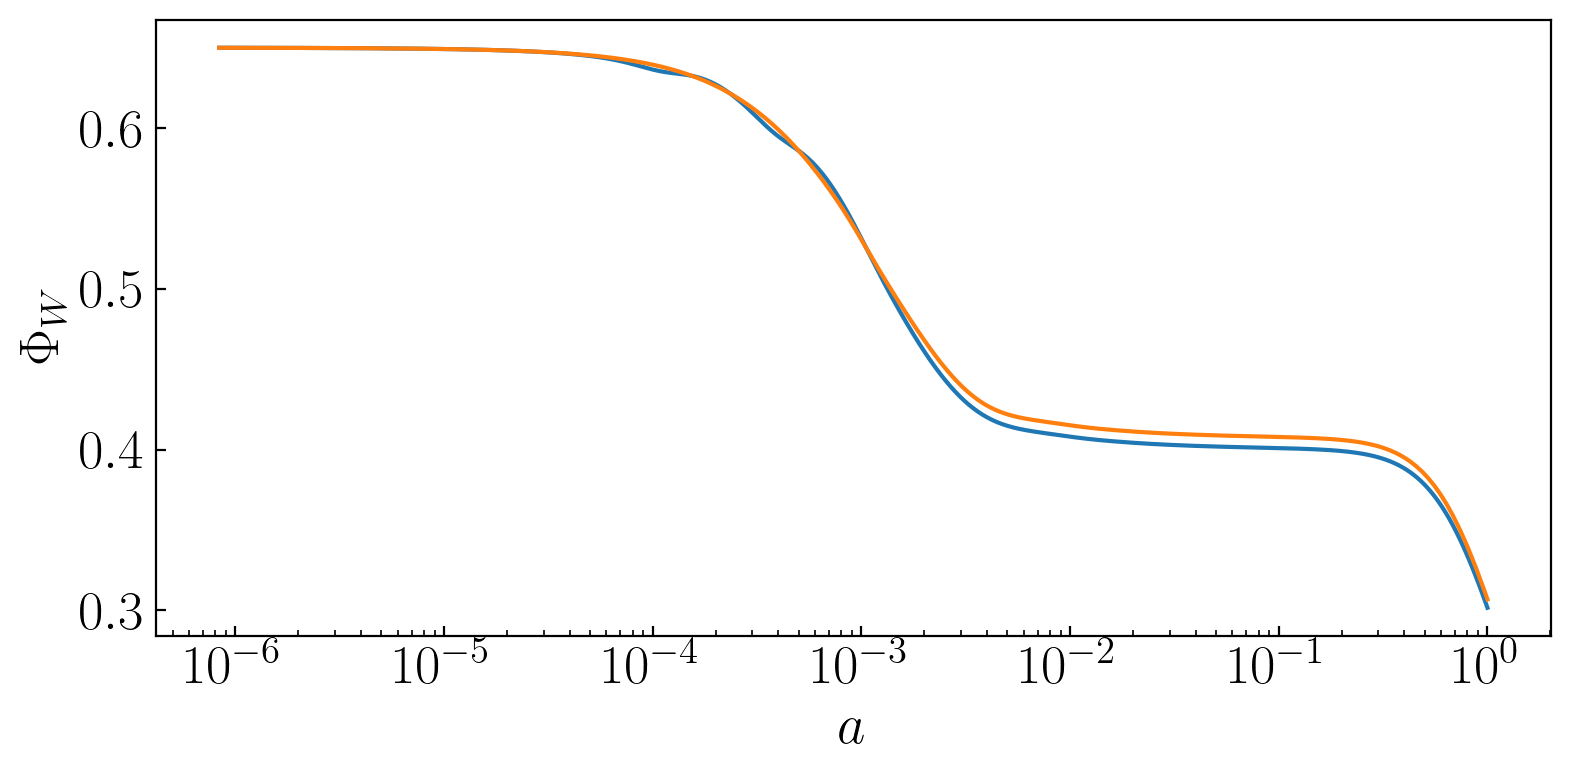

In [9]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k_gedf['a'], (one_k_gedf['psi']+one_k_gedf['phi'])/2.)
plt.semilogx(one_k_lcdm['a'], (one_k_lcdm['psi']+one_k_lcdm['phi'])/2.)

plt.xlabel(r"$a$")
plt.ylabel(r"$\Phi_W$")

Text(0, 0.5, '$\\Phi_W$')

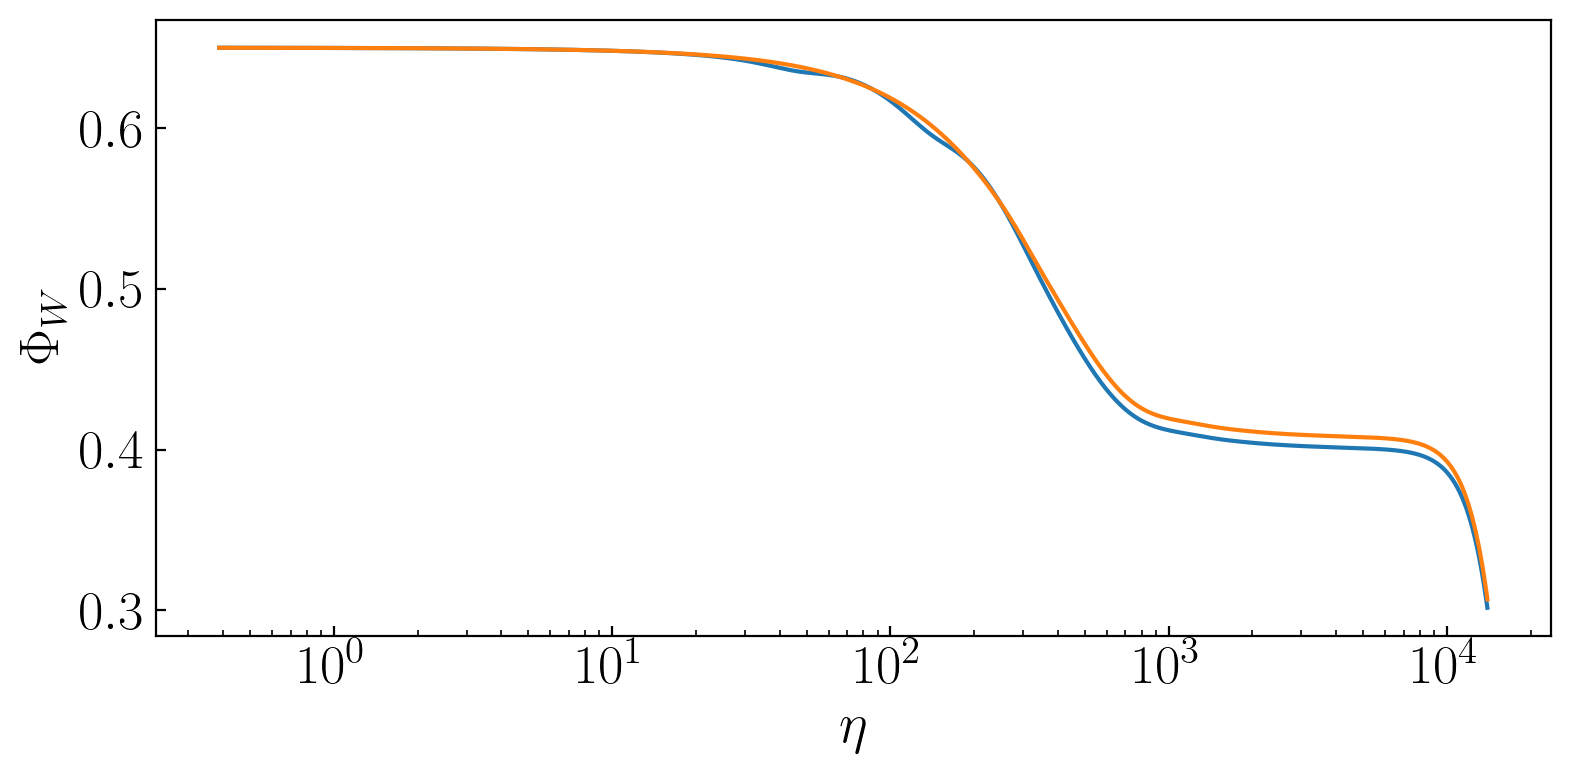

In [15]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k_gedf['tau [Mpc]'], (one_k_gedf['psi']+one_k_gedf['phi'])/2.)
plt.semilogx(one_k_lcdm['tau [Mpc]'], (one_k_lcdm['psi']+one_k_lcdm['phi'])/2.)

plt.xlabel(r"$\eta$")
plt.ylabel(r"$\Phi_W$")

In [10]:
psi_lcdm = np.interp(one_k_gedf['a'], one_k_lcdm['a'], one_k_lcdm['psi'])
phi_lcdm = np.interp(one_k_gedf['a'], one_k_lcdm['a'], one_k_lcdm['phi'])

Text(0, 0.5, '$\\Delta\\Phi_W$')

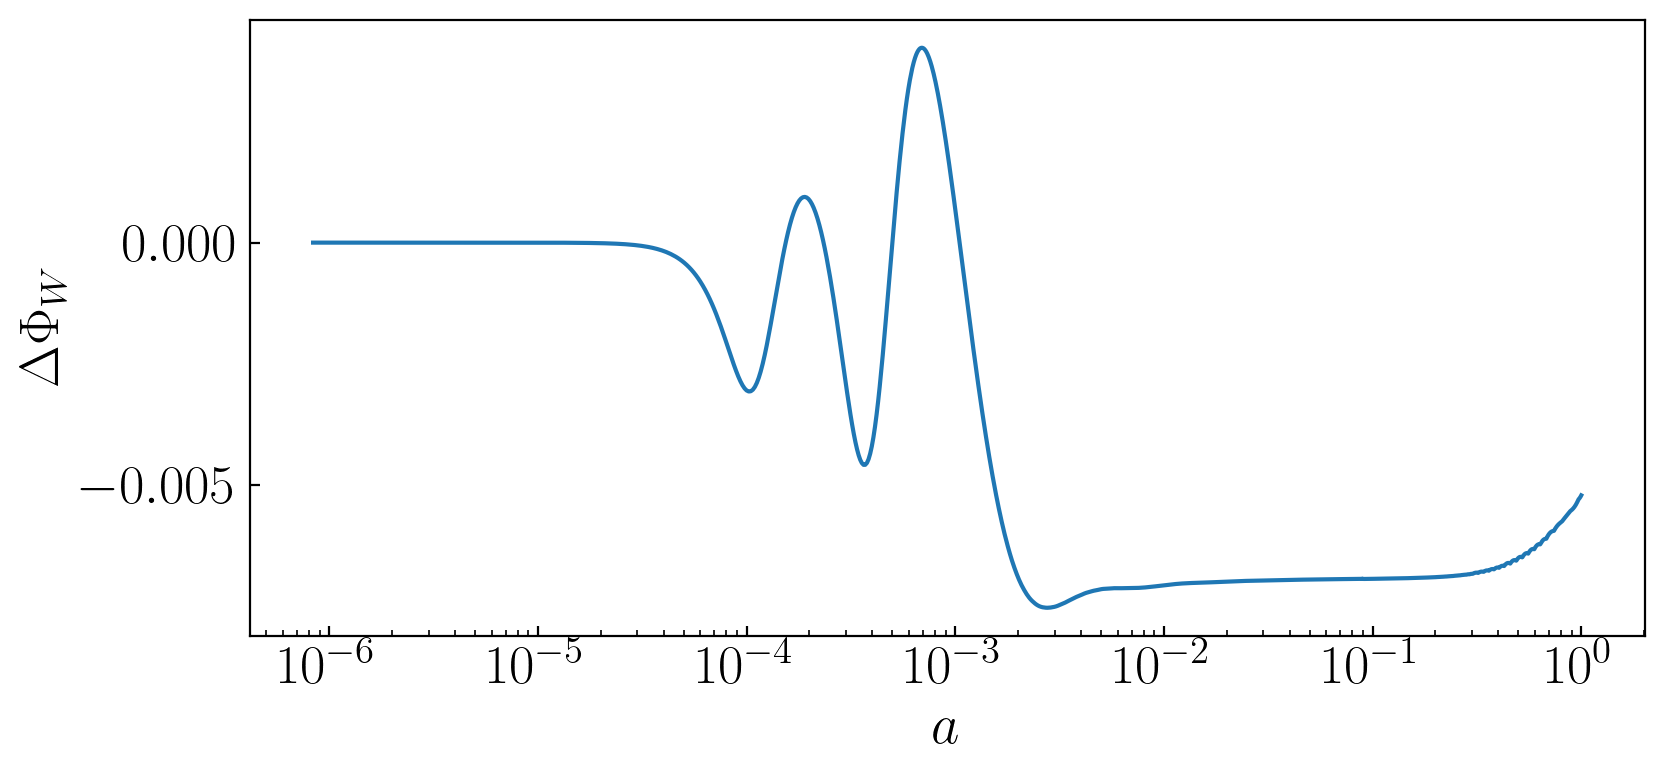

In [11]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k_gedf['a'], (one_k_gedf['psi']+one_k_gedf['phi'] - psi_lcdm - phi_lcdm)/2.)

plt.xlabel(r"$a$")
plt.ylabel(r"$\Delta\Phi_W$")

In [16]:
np.savez('260720_gedf_Weyl.npz', one_k_gedf['tau [Mpc]'], one_k_gedf['psi']+one_k_gedf['phi'], psi_lcdm + phi_lcdm)

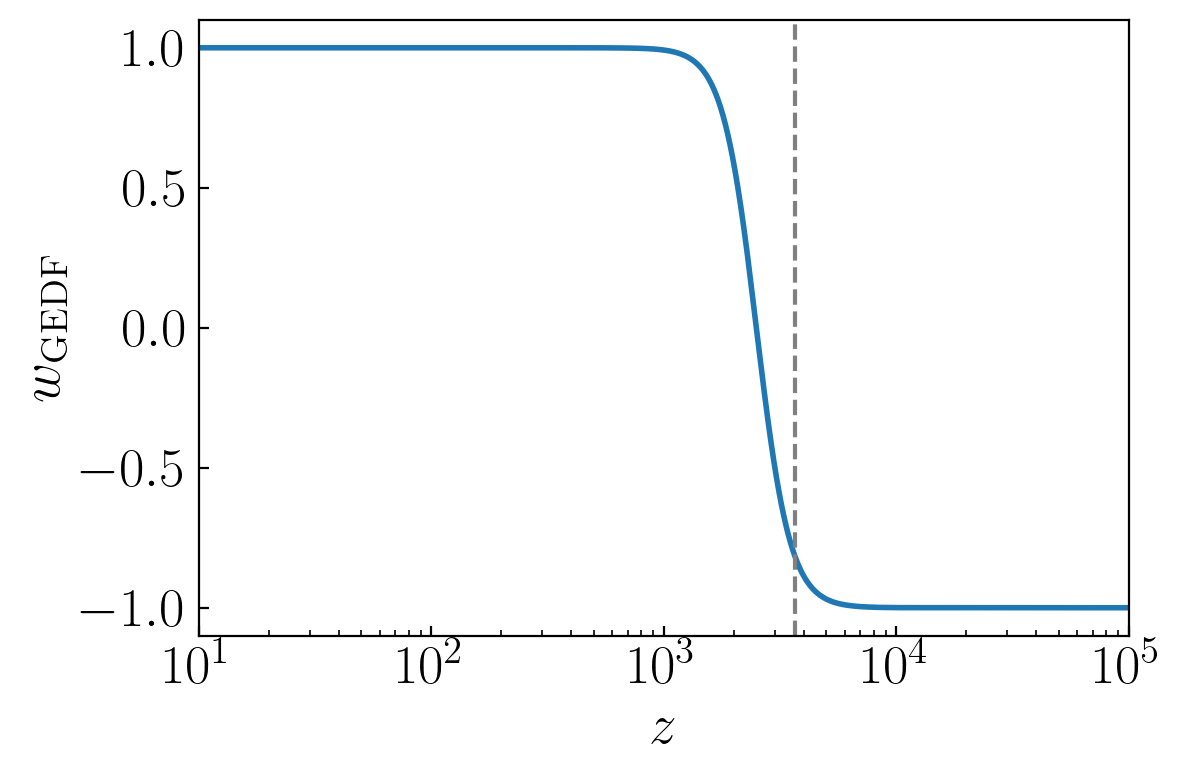

In [4]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)w_gedf'], '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$w_{\mathrm{GEDF}}$')
plt.xlim([1e1, 1e5])
plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.show()

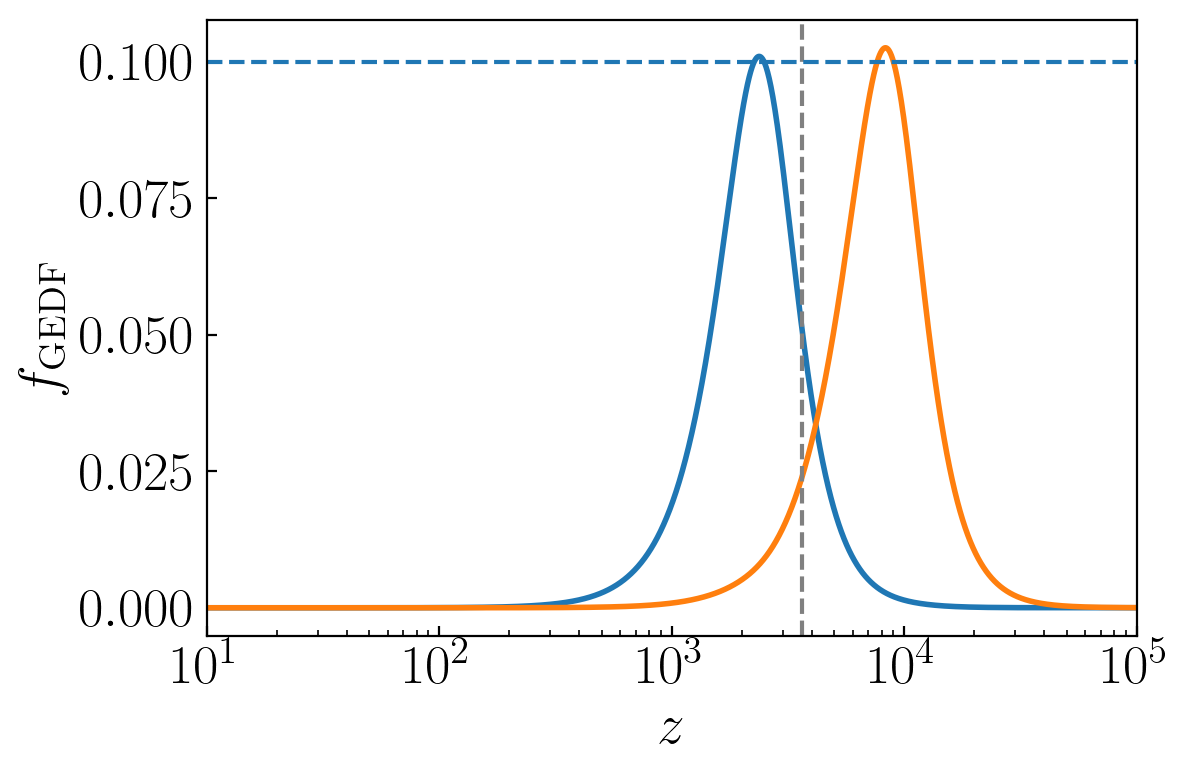

In [5]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_gedf']/(model.get_background()['(.)rho_tot']), '-', linewidth=2, label=r'test')
plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_gedf_2']/(model.get_background()['(.)rho_tot']), '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_{\mathrm{GEDF}}$')
plt.xlim([1e1, 1e5])
plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.axhline(y = 0.1, linestyle = '--')
plt.show()

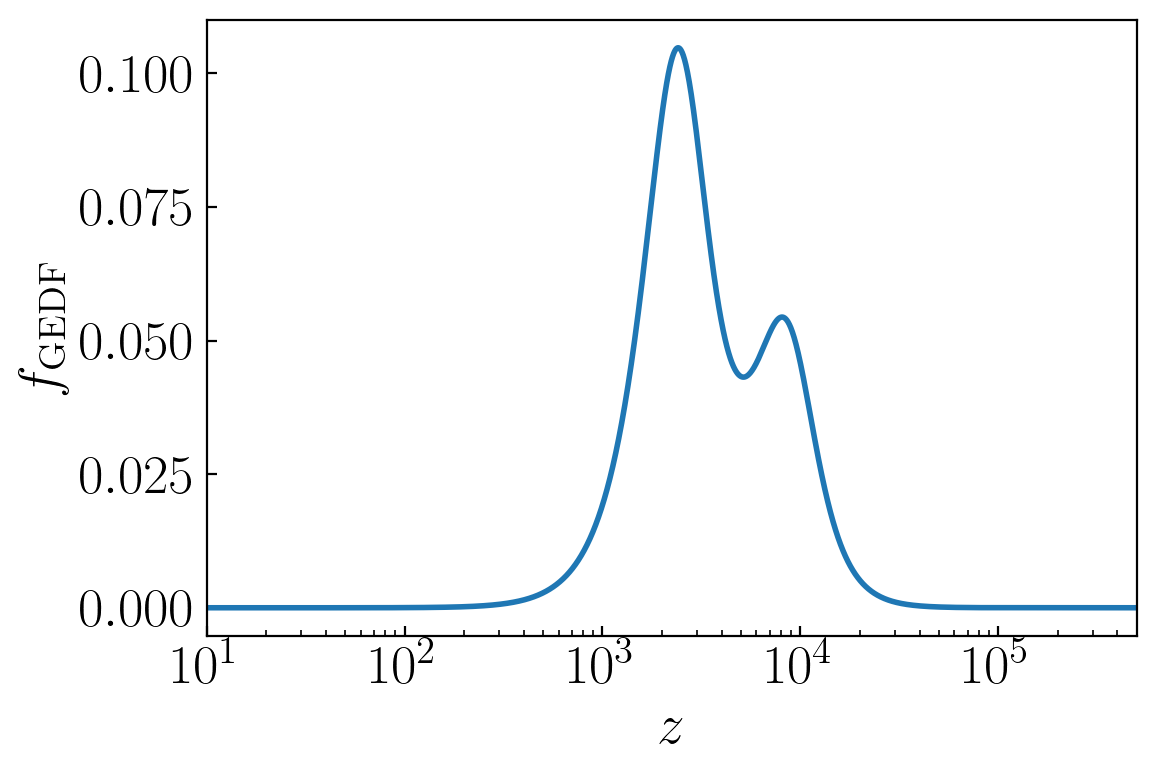

In [8]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], (model.get_background()['(.)rho_gedf'] + model.get_background()['(.)rho_gedf_2'])/(model.get_background()['(.)rho_tot']), '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_{\mathrm{GEDF}}$')
plt.xlim([1e1, 5e5])
# plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
# plt.axhline(y = 0.1, linestyle = '--')
plt.savefig('./260721_f_gedf.png', bbox_inches='tight')
plt.show()

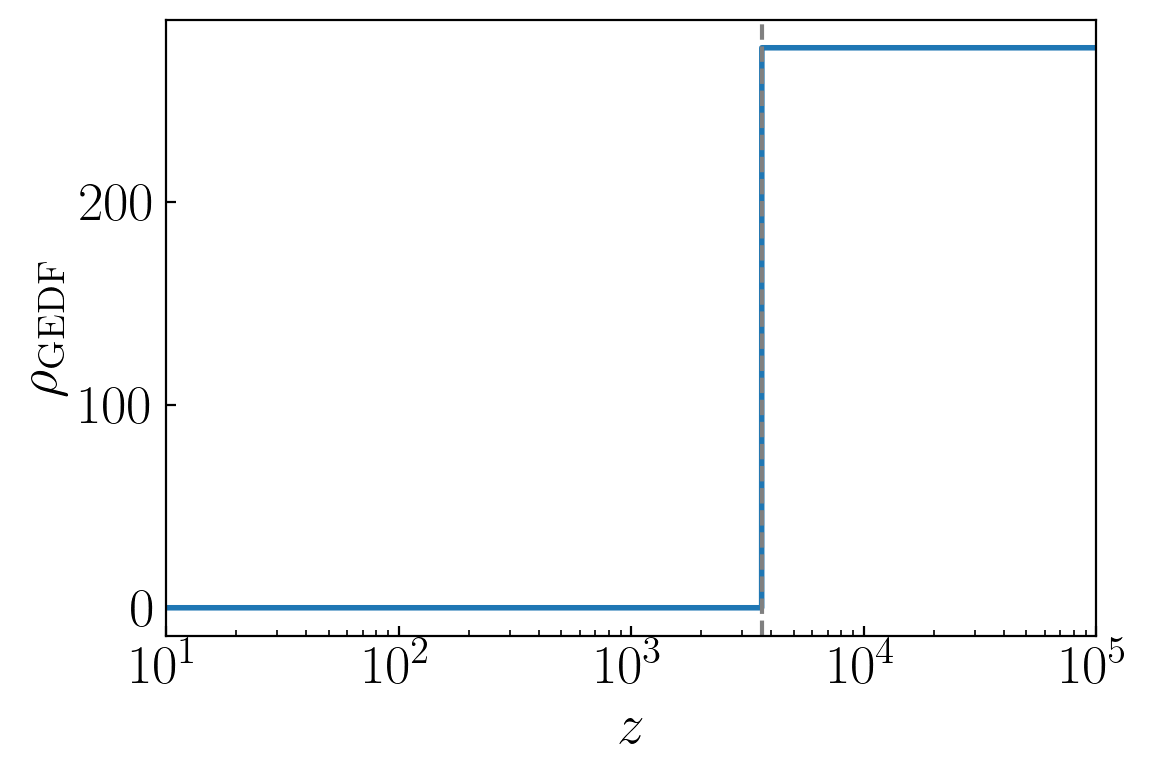

In [28]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_gedf'], '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$\rho_{\mathrm{GEDF}}$')
plt.xlim([1e1, 1e5])
plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.show()

In [11]:
print(model.get_background()['(.)rho_gedf'][0])
# print(model.get_current_derived_parameters(['h'])['h'])

351.4978253744239


In [ ]:
all_k = model.get_perturbations()  # this potentially constains scalars/tensors and all k values
print (all_k['scalar'][0].keys())
#    
one_k = all_k['scalar'][0] 

background = model.get_background()
background_z = background['z']

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_rho_gedf', 'rho_plus_p_theta_gedf', 'delta_p_gedf', 'delta_gedf', 'ca2_gedf_output', 'cs2_gedf_output', 'u_gedf', 'T_h_gedf', 'delta_rho_gedf_2', 'rho_plus_p_theta_gedf_2', 'delta_p_gedf_2', 'delta_gedf_2', 'ca2_gedf_2_output', 'cs2_gedf_2_output', 'u_gedf_2', 'T_h_gedf_2'])


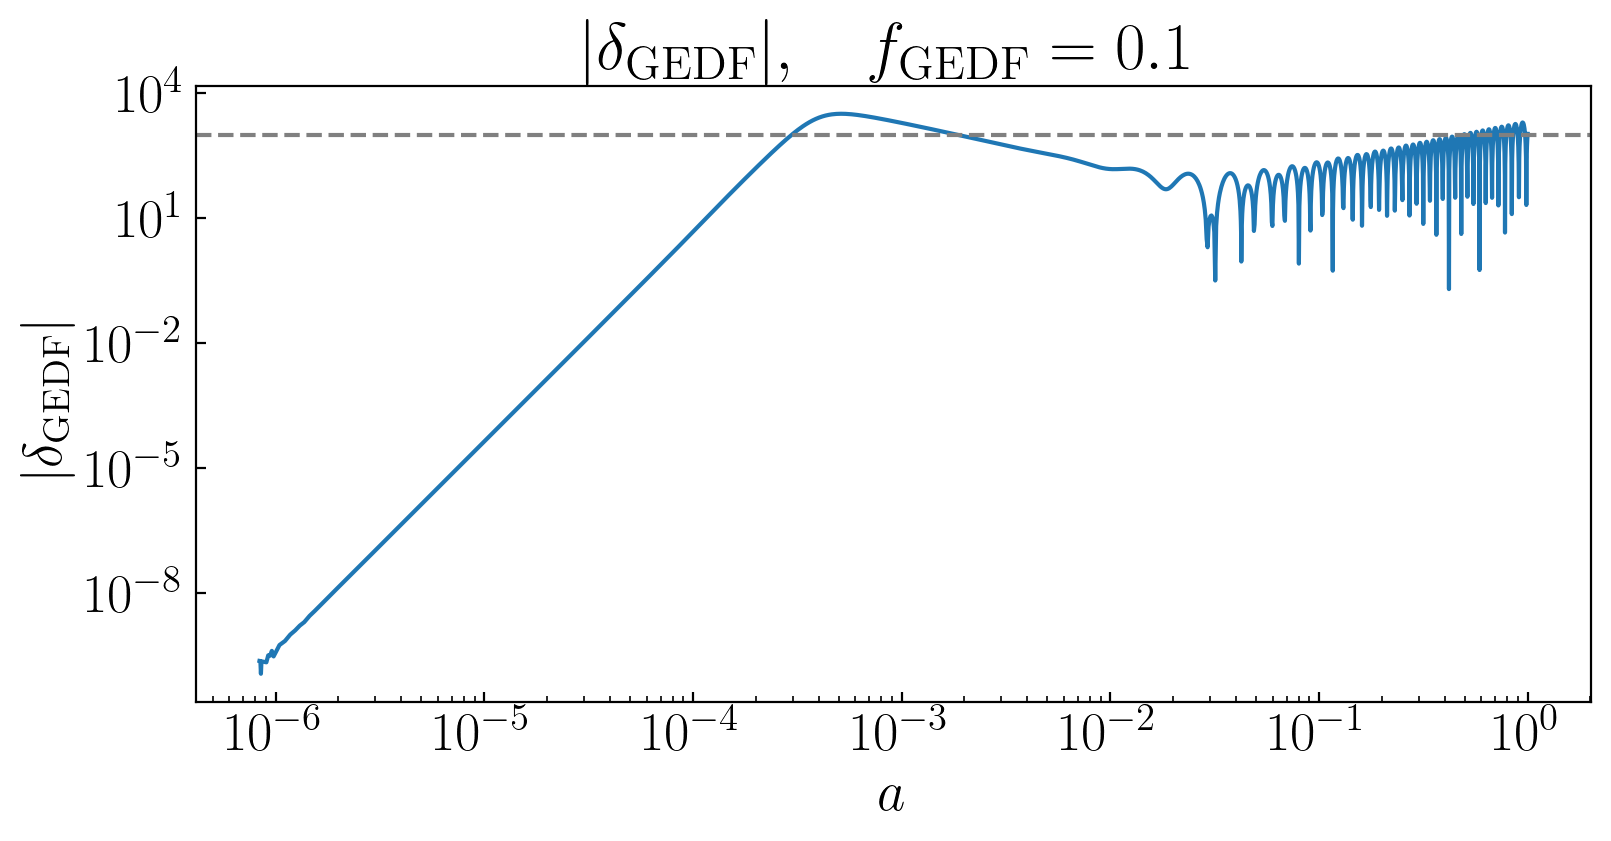

In [16]:
plt.figure(figsize=(9, 4))

plt.loglog(one_k['a'], abs(one_k['delta_gedf']))

plt.xlabel(r"$a$")
plt.ylabel(r"$|\delta_{\mathrm{GEDF}}|$")
plt.title(r"$|\delta_{\mathrm{GEDF}}|,\quad f_{\mathrm{GEDF}} = 0.1$ ")
plt.axhline(y = 1e3, color = 'gray', linestyle = '--')

Text(0, 0.5, '$\\delta_{\\mathrm{GEDF}}$')

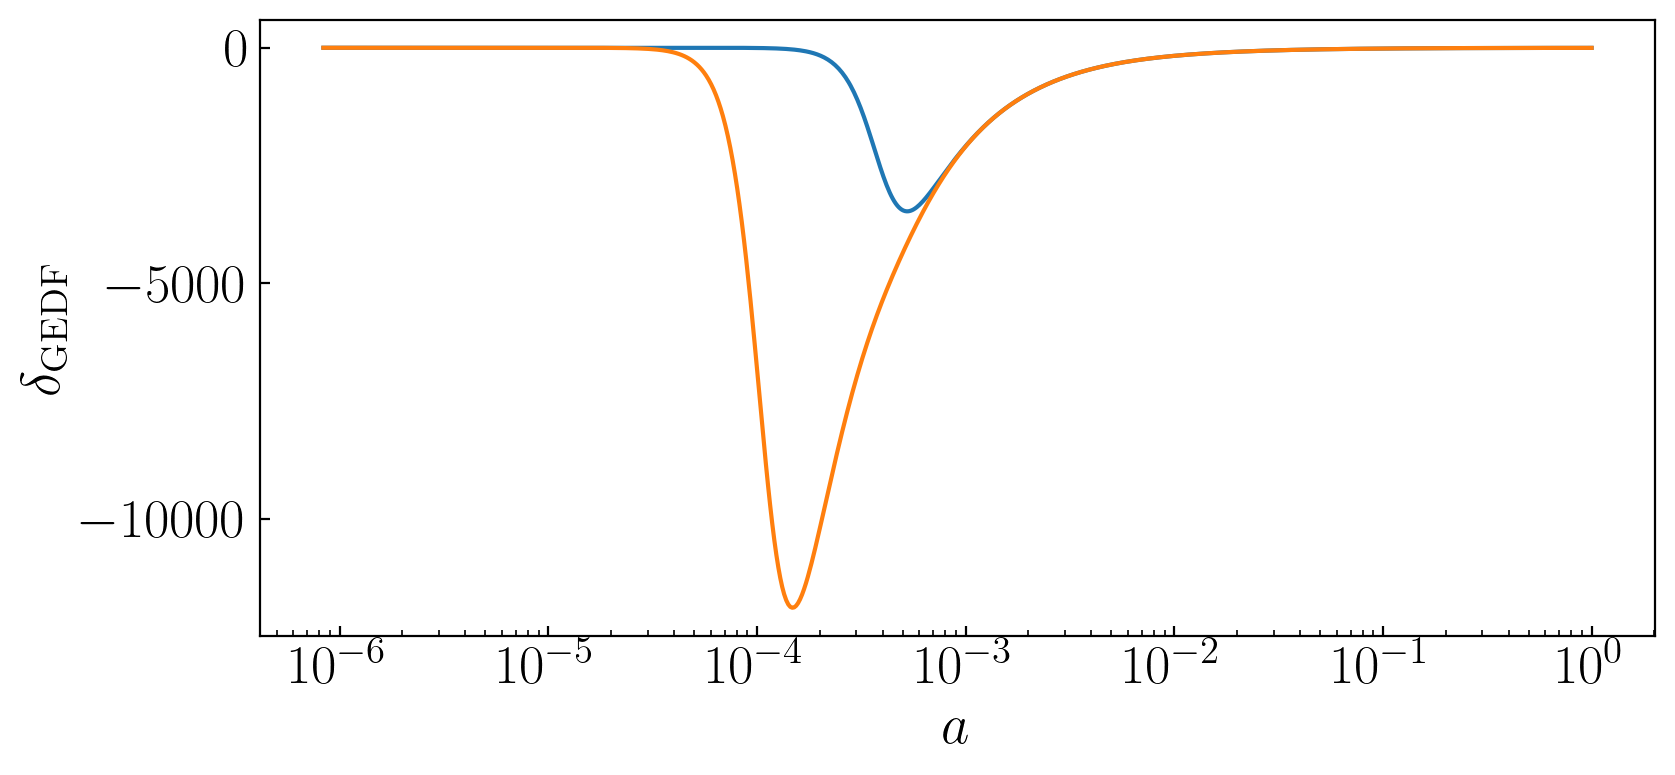

In [12]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['delta_gedf'], label=r'$\delta_{\mathrm{GEDF}}$')
plt.semilogx(one_k['a'], one_k['delta_gedf_2'], label=r'$\delta_{\mathrm{GEDF}}$')
# plt.()
plt.xlabel(r"$a$")
plt.ylabel(r"$\delta_{\mathrm{GEDF}}$")

# from scipy.interpolate import interp1d
# w_gedf_interp = interp1d(model.get_background()['z'], model.get_background()['(.)w_gedf'], kind='cubic', bounds_error=False, fill_value='extrapolate')
# plt.semilogx(one_k['a'], one_k['delta_gedf']*(1. + w_gedf_interp(1./one_k['a'] - 1.)))

Text(0, 0.5, '$\\delta\\rho_{\\mathrm{GEDF}}$')

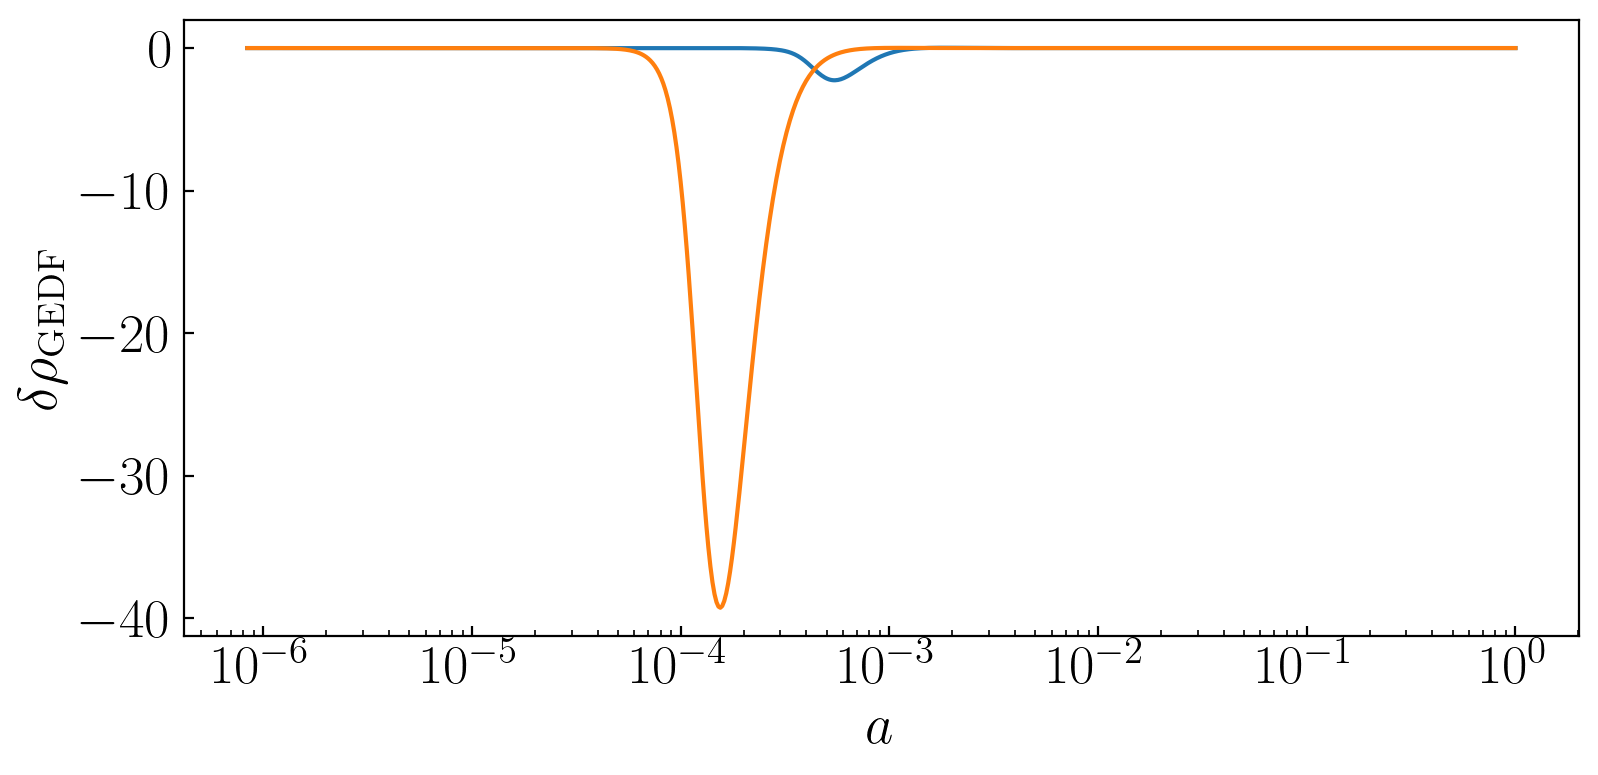

In [23]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['delta_rho_gedf'])
plt.semilogx(one_k['a'], one_k['delta_rho_gedf_2'])
# plt.()
plt.xlabel(r"$a$")
plt.ylabel(r"$\delta\rho_{\mathrm{GEDF}}$")

In [ ]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['delta_gedf'])
# plt.()
plt.xlabel(r"$a$")
plt.ylabel(r"$\delta_a$")

Text(0, 0.5, '$u_{\\mathrm{GEDF}}$')

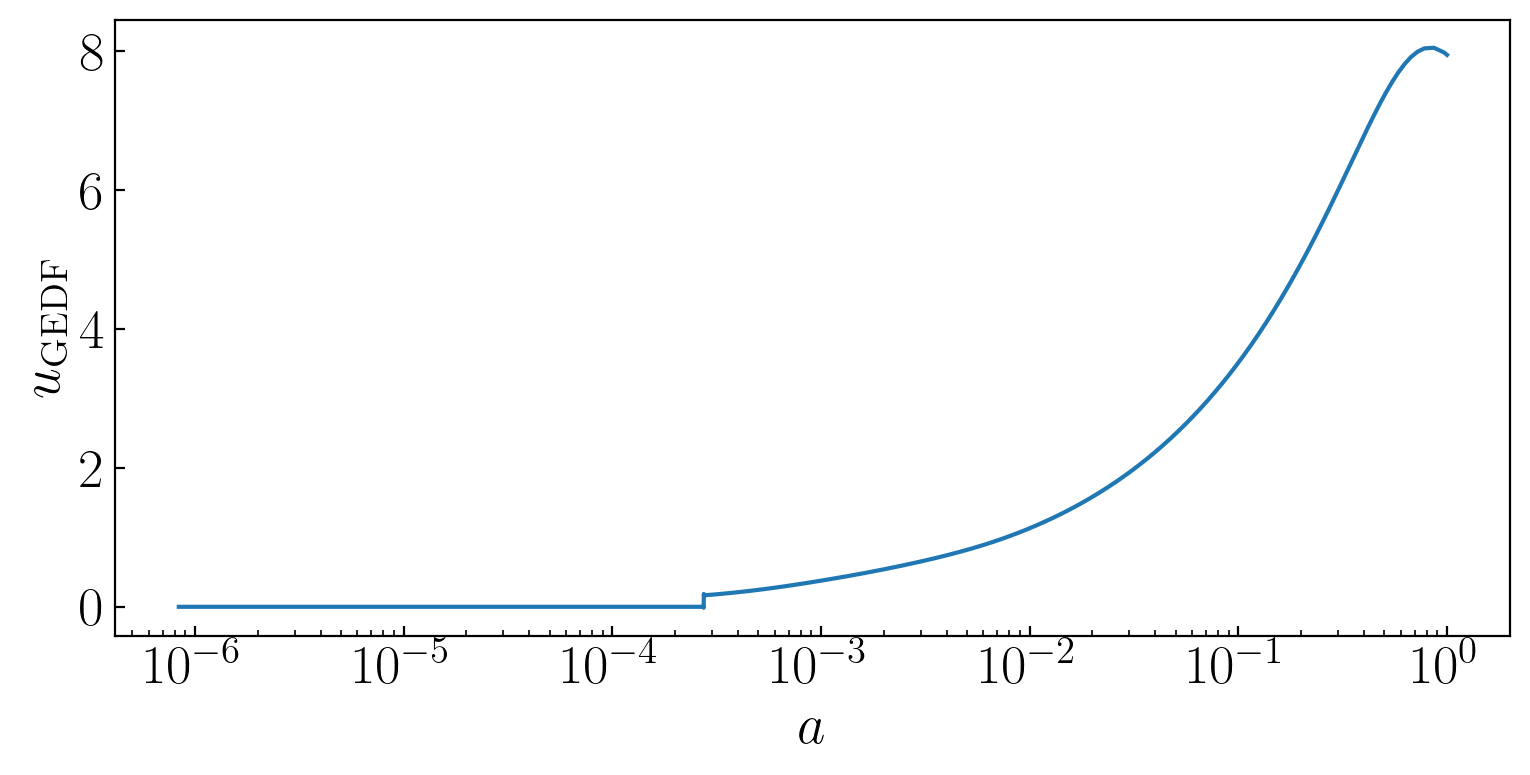

In [43]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['u_gedf'])
# plt.()
plt.xlabel(r"$a$")
plt.ylabel(r"$u_{\mathrm{GEDF}}$")

Text(0, 0.5, '$c_a^2$')

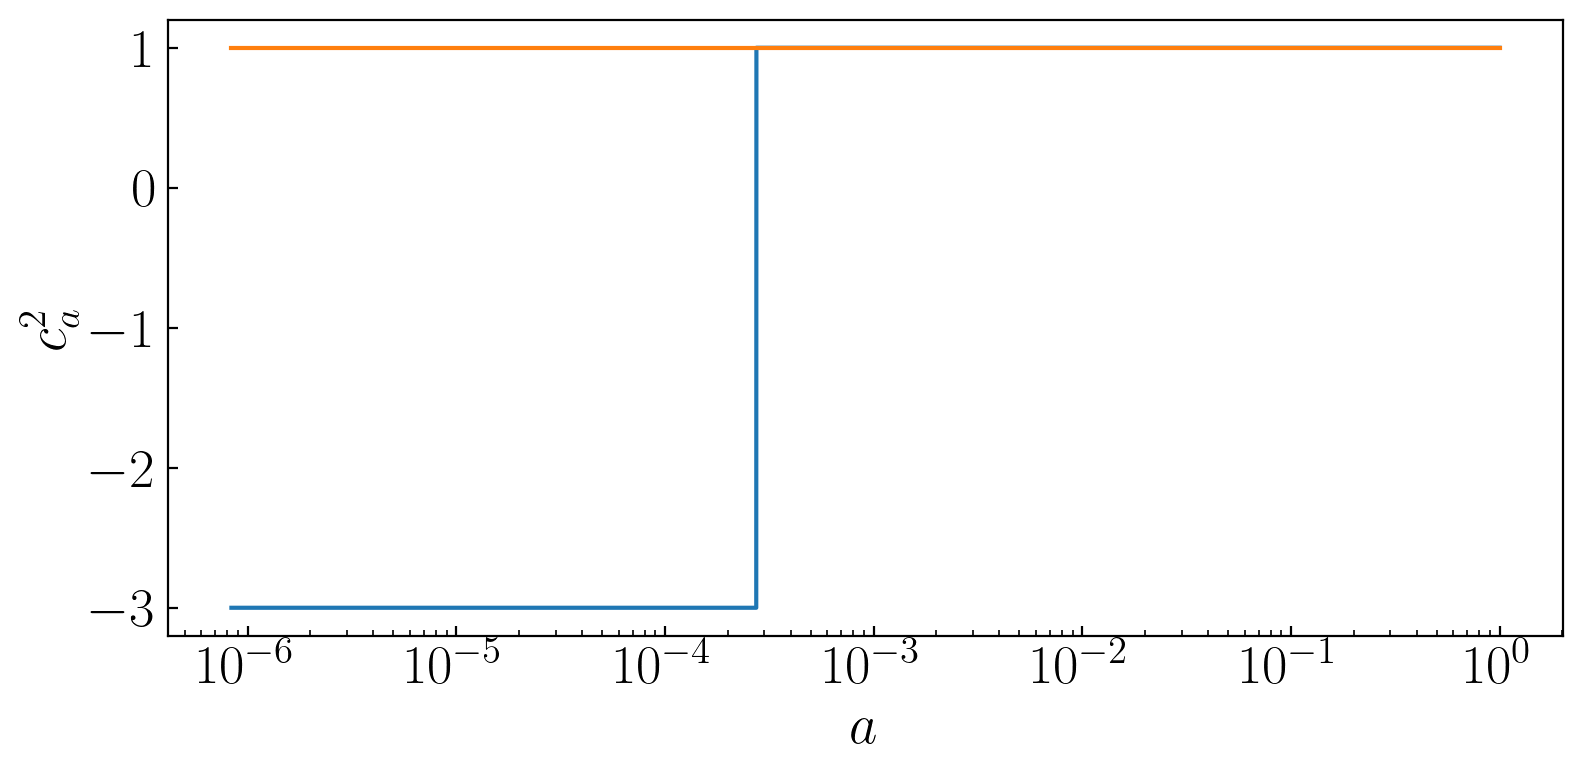

In [34]:
plt.figure(figsize=(9, 4))

plt.semilogx(one_k['a'], one_k['ca2_gedf_output'])
plt.semilogx(one_k['a'], one_k['cs2_gedf_output'])
# plt.()
plt.xlabel(r"$a$")
plt.ylabel(r"$c_a^2$")

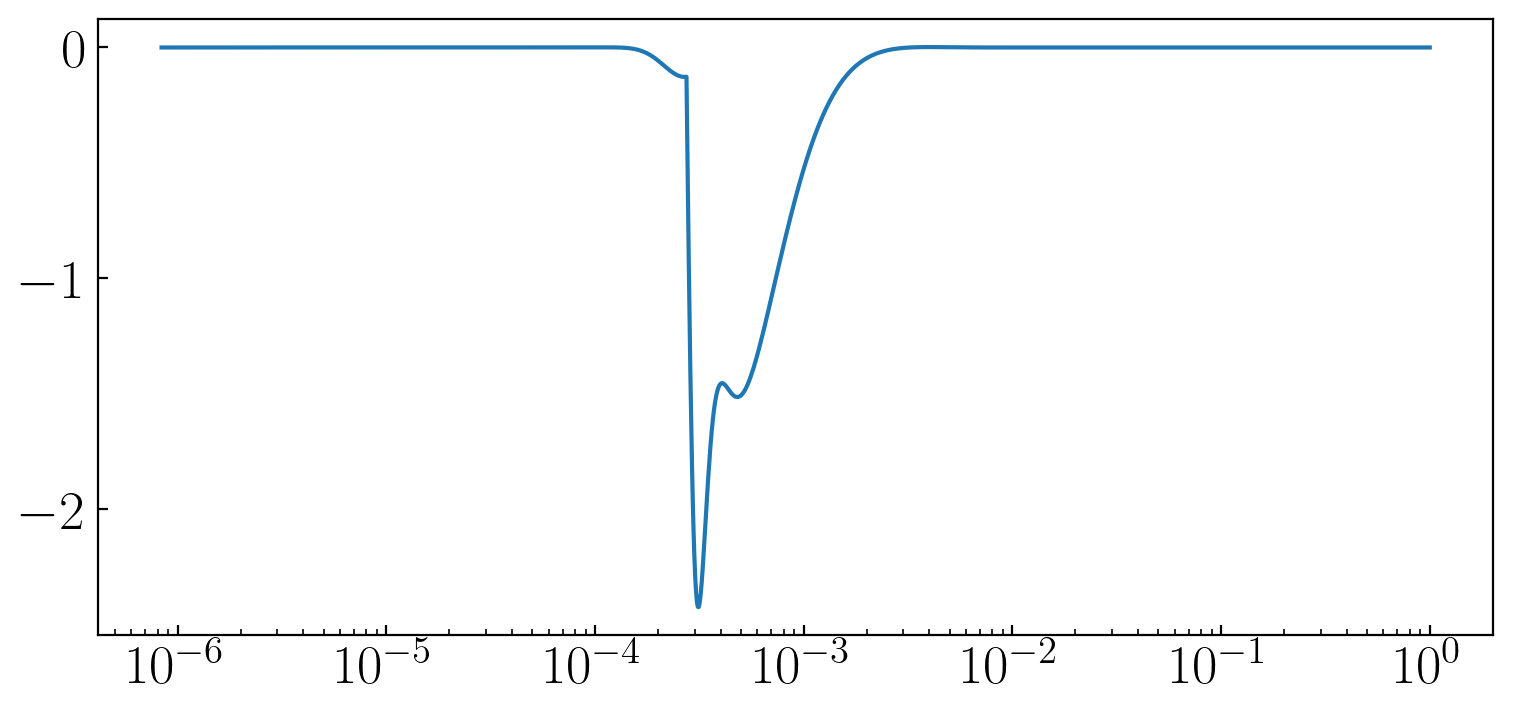

In [8]:
plt.figure(figsize=(9, 4))

from scipy.interpolate import interp1d
delta_gedf_interp = interp1d(model.get_background()['z'], model.get_background()['(.)rho_gedf'], kind='cubic', bounds_error=False, fill_value='extrapolate')
# delta_scf_interp_z= interp1d(ones_delta_scf, model.get_background()['z'], kind='cubic', bounds_error=False, fill_value='extrapolate')
# plt.semilogx(1./one_k['a'] - 1., delta_scf_interp(1./one_k['a'] - 1.))
# plt.semilogx(one_k['a'], delta_scf_interp(1./one_k['a'] - 1.))
# plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_scf'])
plt.semilogx(one_k['a'], one_k['delta_gedf']*delta_gedf_interp(1./one_k['a'] - 1.))

In [21]:
cls = model.lensed_cl(5000)
bg = model.get_background()
ell = cls['ell'][2:].astype(int)

Text(0, 0.5, '$C_\\ell^{TT}$')

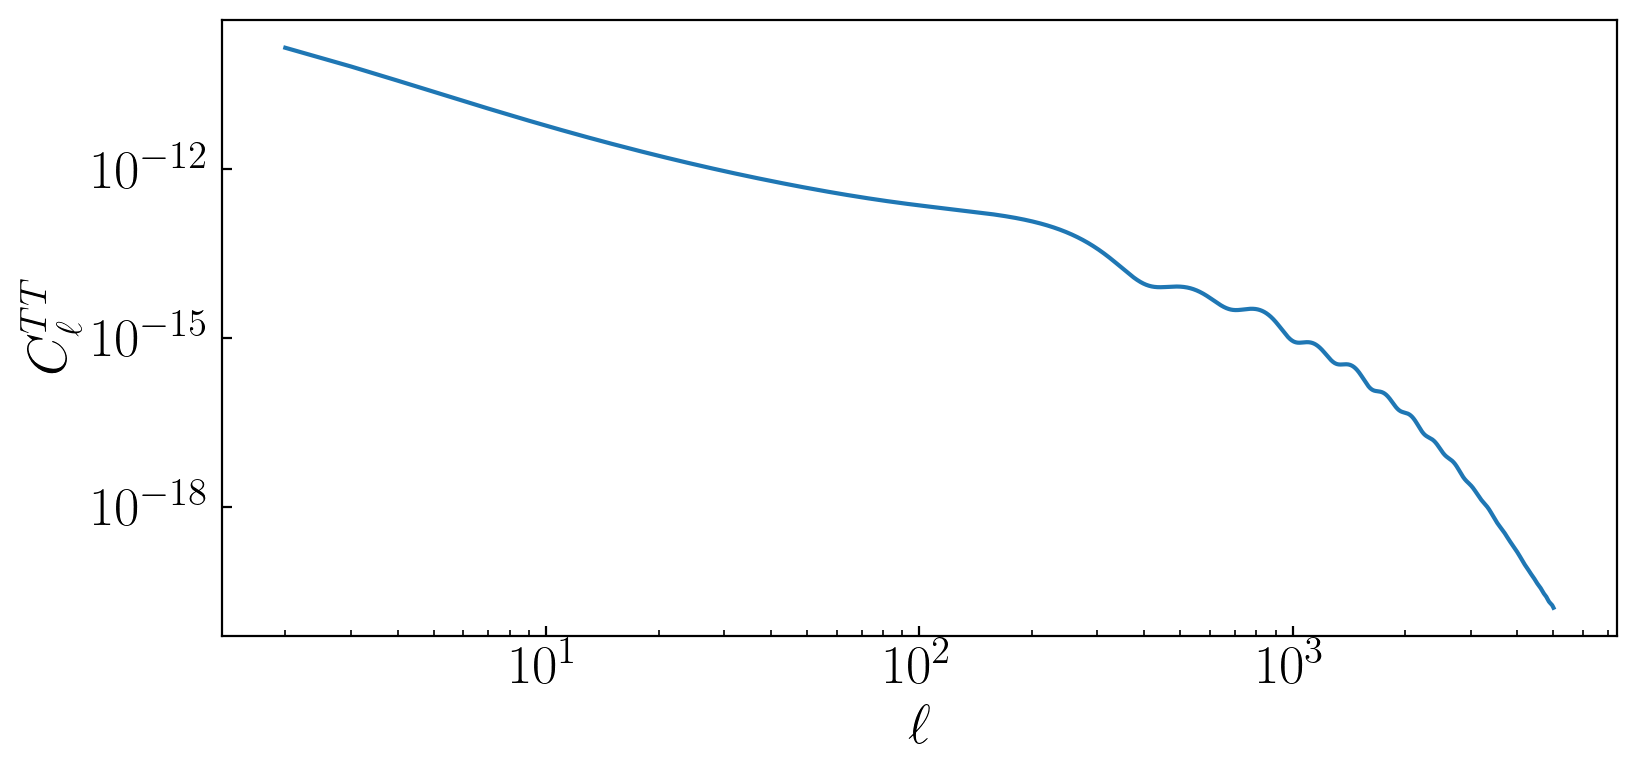

In [23]:
plt.figure(figsize=(9, 4))

plt.loglog(ell, cls['tt'][2:])
# plt.()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{TT}$")